<a href="https://colab.research.google.com/github/Matteoh22/AMD-project/blob/main/MatteoHasa_AMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. SETUP



In [ ]:
!pip install kaggle -q

!pip install pyarrow -q

import os
import re
import json
import math
import time
import zipfile
import itertools
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.sparse import csr_matrix

# 2. DOWNLOAD DATASET FROM KAGGLE



In [ ]:
!pip install -q kaggle

import os
import zipfile

os.environ['KAGGLE_USERNAME'] = "matteohasa"
os.environ['KAGGLE_KEY'] = "KGAT_4633d42ffc430525d9b7e397981ddd41"

!kaggle datasets download -d Cornell-University/arxiv

with zipfile.ZipFile("arxiv.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
 99% 1.58G/1.59G [00:26<00:00, 89.8MB/s]
100% 1.59G/1.59G [00:26<00:00, 63.3MB/s]
Dataset downloaded and extracted.


# 3. INSPECT DATASET STRUCTURE

In [ ]:
path = "/content/data/arxiv-metadata-oai-snapshot.json"

with open(path, "r") as f:
    for i in range(3):
        obj = json.loads(next(f))
        print(f"\n--- Record {i+1} ---")
        print("Keys:", obj.keys())
        print("ID:", obj.get("id"))
        print("Authors:", obj.get("authors"))
        print("Authors parsed:", obj.get("authors_parsed"))
        print("Title:", obj.get("title"))
        print("Categories:", obj.get("categories"))


--- Record 1 ---
Keys: dict_keys(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'])
ID: 0704.0001
Authors: C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan
Authors parsed: [['Balázs', 'C.', ''], ['Berger', 'E. L.', ''], ['Nadolsky', 'P. M.', ''], ['Yuan', 'C. -P.', '']]
Title: Calculation of prompt diphoton production cross sections at Tevatron and
  LHC energies
Categories: hep-ph

--- Record 2 ---
Keys: dict_keys(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'])
ID: 0704.0002
Authors: Ileana Streinu and Louis Theran
Authors parsed: [['Streinu', 'Ileana', ''], ['Theran', 'Louis', '']]
Title: Sparsity-certifying Graph Decompositions
Categories: math.CO cs.CG

--- Record 3 ---
Keys: dict_keys(['id', 'submitter', 'authors', 'title', 'comments', 'j

# 4. HELPER FUNCTIONS

In [ ]:

def normalize_author_name(name: str) -> str:
    if not isinstance(name, str):
        return ""

    name = name.replace("\\'", "'")
    name = name.replace("\n", " ").replace("\r", " ")
    name = re.sub(r"\s+", " ", name.strip().lower())
    name = re.sub(r"[^a-z0-9\s\.\-']", "", name)
    return name.strip()



def parse_authors_from_parsed(authors_parsed):
    if not isinstance(authors_parsed, list):
        return []

    authors = []

    for item in authors_parsed:
        if not isinstance(item, list):
            continue

        parts = []
        for x in item:
            if isinstance(x, str) and x.strip():
                parts.append(x.strip())

        if not parts:
            continue

        full_name = " ".join(parts)
        full_name = normalize_author_name(full_name)

        if not full_name:
            continue
        if re.fullmatch(r"\d+", full_name):
            continue
        if len(full_name) < 3:
            continue

        authors.append(full_name)

    # remove duplicates
    authors = list(dict.fromkeys(authors))
    return authors

# 5. BUILD COAUTHORSHIP EDGE WEIGHTS

In [ ]:
path = "/content/data/arxiv-metadata-oai-snapshot.json"

MAX_PAPERS = 200000
PROGRESS_EVERY = 50000

edge_weights = Counter()
paper_count = 0
usable_papers = 0
author_frequency = Counter()
authors_per_paper = []

with open(path, "r") as f:
    for i, line in enumerate(f):
        if MAX_PAPERS is not None and i >= MAX_PAPERS:
            break

        paper = json.loads(line)
        paper_count += 1

        author_list = parse_authors_from_parsed(paper.get("authors_parsed"))

        if len(author_list) < 2:
            continue

        usable_papers += 1
        authors_per_paper.append(len(author_list))

        for a in author_list:
            author_frequency[a] += 1

        for a, b in itertools.combinations(sorted(author_list), 2):
            edge_weights[(a, b)] += 1

        if paper_count % PROGRESS_EVERY == 0:
            print(f"Processed {paper_count:,} papers | unique edges: {len(edge_weights):,}")

print("\nFinished.")
print(f"Total papers processed: {paper_count:,}")
print(f"Usable papers with at least 2 authors: {usable_papers:,}")
print(f"Unique undirected edges: {len(edge_weights):,}")
print(f"Unique authors seen: {len(author_frequency):,}")

Processed 50,000 papers | unique edges: 522,873
Processed 100,000 papers | unique edges: 1,221,774
Processed 200,000 papers | unique edges: 6,839,278

Finished.
Total papers processed: 200,000
Usable papers with at least 2 authors: 147,107
Unique undirected edges: 6,839,278
Unique authors seen: 232,266


# 6. BASIC STATISTICS

Authors per paper statistics:
count    147107.000000
mean          4.241341
std          11.625930
min           2.000000
25%           2.000000
50%           3.000000
75%           4.000000
max        2607.000000
dtype: float64


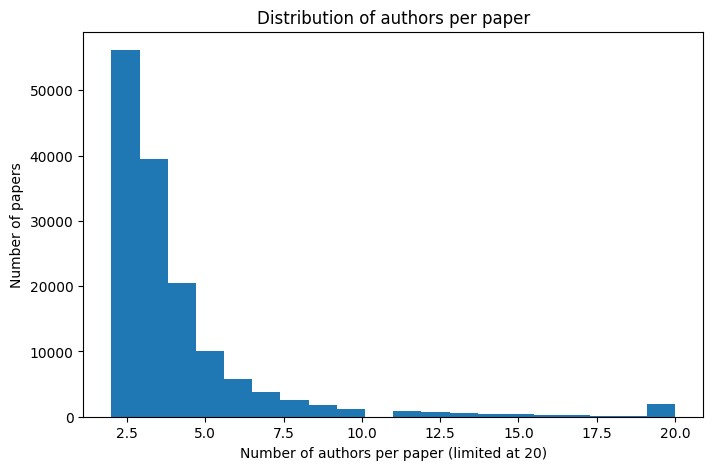

,author,paper_count
1,the babar collaboration,187
2,aubert b.,175
3,poor h. vincent,140
4,gehrels n.,118
5,sarma s. das,117
6,chablat damien irccyn,116
7,aickelin uwe,107
8,canfield p. c.,101
9,aaltonen t.,101
10,d0 collaboration,98


In [ ]:
authors_per_paper = np.array(authors_per_paper)

print("Authors per paper statistics:")
print(pd.Series(authors_per_paper).describe())

plt.figure(figsize=(8, 5))
plt.hist(np.clip(authors_per_paper, 0, 20), bins=20)
plt.xlabel("Number of authors per paper (limited at 20)")
plt.ylabel("Number of papers")
plt.title("Distribution of authors per paper")
plt.show()

top_authors_by_papers = pd.DataFrame(
    author_frequency.most_common(20),
    columns=["author", "paper_count"]
)

top_authors_by_papers.index = top_authors_by_papers.index + 1


top_authors_by_papers

# 7. EDGE LIST DATAFRAME

In [ ]:
edges_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in edge_weights.items()],
    columns=["author_1", "author_2", "weight"]
)

edges_df.index = edges_df.index + 1


print(edges_df.shape)
edges_df.head()

(6839278, 3)


,author_1,author_2,weight
1,balzs c.,berger e. l.,1
2,balzs c.,nadolsky p. m.,1
3,balzs c.,yuan c. -p.,1
4,berger e. l.,nadolsky p. m.,1
5,berger e. l.,yuan c. -p.,1


# 8. SPARSE GRAPH CONSTRUCTION


In [ ]:
authors = pd.Index(sorted(set(edges_df["author_1"]).union(set(edges_df["author_2"]))))
author_to_id = pd.Series(np.arange(len(authors)), index=authors)

n = len(authors)
print(f"Number of nodes (authors): {n}")

src = edges_df["author_1"].map(author_to_id).to_numpy()
dst = edges_df["author_2"].map(author_to_id).to_numpy()
w = edges_df["weight"].to_numpy(dtype=np.float64)

row_idx = np.concatenate([src, dst])
col_idx = np.concatenate([dst, src])
data = np.concatenate([w, w])

A = csr_matrix((data, (row_idx, col_idx)), shape=(n, n), dtype=np.float64)

print("Adjacency matrix shape:", A.shape)
print("Nonzero entries:", A.nnz)

Number of nodes (authors): 232266
Adjacency matrix shape: (232266, 232266)
Nonzero entries: 13678556


# 9. PAGERANK IMPLEMENTATION

In [ ]:
def compute_pagerank_sparse(A, alpha=0.85, tol=1e-8, max_iter=100, verbose=True):

    # Number of nodes
    n = A.shape[0]

    # Compute outgoing weights of each node
    out_strength = np.asarray(A.sum(axis=1)).flatten()
    dangling = (out_strength == 0)

    # Build normalization matrix
    inv_out = np.zeros_like(out_strength, dtype=np.float64)
    inv_out[out_strength > 0] = 1.0 / out_strength[out_strength > 0]
    D_inv = sparse.diags(inv_out)

    # Transition probability matrix
    P = D_inv @ A

    # Initialize PageRank vector
    r = np.ones(n, dtype=np.float64) / n
    teleport = np.ones(n, dtype=np.float64) / n

    # Iterative PageRank computation
    for it in range(max_iter):

        r_old = r.copy()

        # Contribution of dangling nodes
        dangling_mass = r_old[dangling].sum()

        # PageRank update
        r = alpha * (P.T @ r_old)
        r += alpha * dangling_mass * teleport
        r += (1 - alpha) * teleport

        # Convergence check
        diff = np.linalg.norm(r - r_old, ord=1)

        if verbose:
            print(f"Iteration {it+1:3d} | L1 diff = {diff:.3e}")

        if diff < tol:
            if verbose:
                print(f"Converged in {it+1} iterations.")
            break

    return r


pagerank_scores = compute_pagerank_sparse(
    A,
    alpha=0.85,
    tol=1e-8,
    max_iter=100,
    verbose=True
)

# Verify normalization
print(f"Sum of PageRank scores: {pagerank_scores.sum():.6f}")

Iteration   1 | L1 diff = 4.531e-01
Iteration   2 | L1 diff = 1.539e-01
Iteration   3 | L1 diff = 7.121e-02
Iteration   4 | L1 diff = 4.300e-02
Iteration   5 | L1 diff = 2.824e-02
Iteration   6 | L1 diff = 1.973e-02
Iteration   7 | L1 diff = 1.443e-02
Iteration   8 | L1 diff = 1.082e-02
Iteration   9 | L1 diff = 8.317e-03
Iteration  10 | L1 diff = 6.477e-03
Iteration  11 | L1 diff = 5.123e-03
Iteration  12 | L1 diff = 4.084e-03
Iteration  13 | L1 diff = 3.288e-03
Iteration  14 | L1 diff = 2.661e-03
Iteration  15 | L1 diff = 2.167e-03
Iteration  16 | L1 diff = 1.771e-03
Iteration  17 | L1 diff = 1.454e-03
Iteration  18 | L1 diff = 1.197e-03
Iteration  19 | L1 diff = 9.882e-04
Iteration  20 | L1 diff = 8.179e-04
Iteration  21 | L1 diff = 6.783e-04
Iteration  22 | L1 diff = 5.637e-04
Iteration  23 | L1 diff = 4.691e-04
Iteration  24 | L1 diff = 3.911e-04
Iteration  25 | L1 diff = 3.264e-04
Iteration  26 | L1 diff = 2.727e-04
Iteration  27 | L1 diff = 2.281e-04
Iteration  28 | L1 diff = 1.

# 10. TOP AUTHORS BY PAGERANK

In [ ]:
pagerank_df = pd.DataFrame({
    "author": authors,
    "pagerank": pagerank_scores
}).sort_values("pagerank", ascending=False).reset_index(drop=True)

pagerank_df.index = pagerank_df.index + 1


pagerank_df.head(20)

,author,pagerank
1,poor h. vincent,0.000134
2,schneider donald p.,0.000089
3,gehrels n.,0.000081
4,canfield p. c.,0.000079
5,nori franco,0.000077
6,guo guang-can,0.000076
7,leydesdorff loet,0.000075
8,aickelin uwe,0.000073
9,chablat damien irccyn,0.000070
10,zhou tao,0.000069


# 11. Baseline rankings

PageRank comparison with:<br>
	•	weighted degree<br>
	•	unweighted degree<br>
	•	paper count<br><br>

### 11.1 WEIGHTED DEGREE


In [ ]:
weighted_degree = np.asarray(A.sum(axis=1)).flatten()

weighted_degree_df = pd.DataFrame({
    "author": authors,
    "weighted_degree": weighted_degree
}).sort_values("weighted_degree", ascending=False).reset_index(drop=True)

weighted_degree_df.index = weighted_degree_df.index + 1

weighted_degree_df.head(20)

,author,weighted_degree
1,li x.,7677.0
2,goggin l. m.,7307.0
3,jones g.,7139.0
4,brau j. e.,7021.0
5,sato s.,6613.0
6,colas j.,6314.0
7,vrba v.,6155.0
8,buchholz p.,6073.0
9,ziolkowski m.,6060.0
10,liu h.,6023.0


### 11.2 UNWEIGHTED DEGREE

In [ ]:
A_binary = A.copy()
A_binary.data = np.ones_like(A_binary.data)

unweighted_degree = np.asarray(A_binary.sum(axis=1)).flatten()

unweighted_degree_df = pd.DataFrame({
    "author": authors,
    "unweighted_degree": unweighted_degree
}).sort_values("unweighted_degree", ascending=False).reset_index(drop=True)

unweighted_degree_df.index = unweighted_degree_df.index + 1

unweighted_degree_df.head(20)

,author,unweighted_degree
1,zhang j.,4174.0
2,martin a.,4040.0
3,li j.,3989.0
4,kim s. h.,3783.0
5,stenzel h.,3704.0
6,li x.,3636.0
7,jones g.,3611.0
8,xie y.,3541.0
9,yang z.,3495.0
10,brau j. e.,3494.0


### 11.3 NUMBER OF PAPERS

In [ ]:
paper_count_df = pd.DataFrame(
    author_frequency.items(),
    columns=["author", "paper_count"]
).sort_values("paper_count", ascending=False).reset_index(drop=True)

paper_count_df.index = paper_count_df.index + 1

paper_count_df.head(20)

,author,paper_count
1,the babar collaboration,187
2,aubert b.,175
3,poor h. vincent,140
4,gehrels n.,118
5,sarma s. das,117
6,chablat damien irccyn,116
7,aickelin uwe,107
8,aaltonen t.,101
9,canfield p. c.,101
10,d0 collaboration,98


# 12. MERGE RESULTS

In [ ]:
results = pagerank_df.merge(weighted_degree_df, on="author", how="left")
results = results.merge(unweighted_degree_df, on="author", how="left")
results = results.merge(paper_count_df, on="author", how="left")

results["rank_pagerank"] = results["pagerank"].rank(method="dense", ascending=False).astype(int)
results["rank_weighted_degree"] = results["weighted_degree"].rank(method="dense", ascending=False).astype(int)
results["rank_unweighted_degree"] = results["unweighted_degree"].rank(method="dense", ascending=False).astype(int)
results["rank_paper_count"] = results["paper_count"].rank(method="dense", ascending=False).astype(int)

results.index = results.index + 1
results.head(20)

,author,pagerank,weighted_degree,unweighted_degree,paper_count,rank_pagerank,rank_weighted_degree,rank_unweighted_degree,rank_paper_count
1,poor h. vincent,0.000134,343.0,129.0,140,1,1980,1097,3
2,schneider donald p.,0.000089,1390.0,706.0,68,2,1199,539,25
3,gehrels n.,0.000081,3048.0,1294.0,118,3,459,309,4
4,canfield p. c.,0.000079,887.0,310.0,101,4,1476,916,8
5,nori franco,0.000077,296.0,122.0,96,5,2027,1104,10
6,guo guang-can,0.000076,295.0,117.0,69,6,2028,1109,24
7,leydesdorff loet,0.000075,99.0,57.0,78,7,2224,1169,17
8,aickelin uwe,0.000073,206.0,66.0,107,8,2117,1160,7
9,chablat damien irccyn,0.000070,266.0,67.0,116,9,2057,1159,6
10,zhou tao,0.000069,193.0,93.0,58,10,2130,1133,35


# 13. CORRELATION BETWEEN RANKING MEASURES

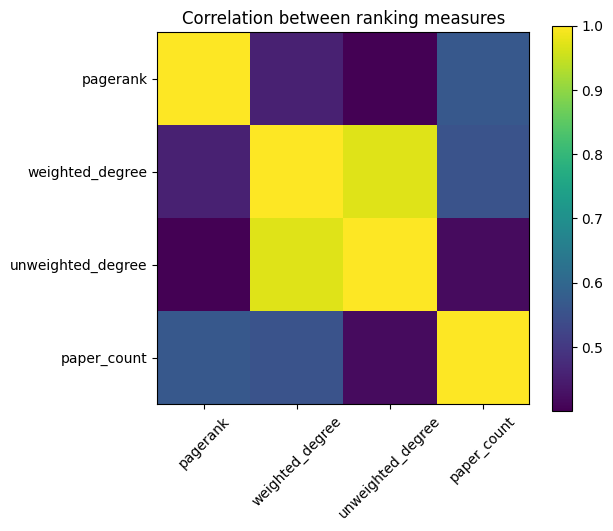

In [ ]:
corr = results[["pagerank", "weighted_degree", "unweighted_degree", "paper_count"]].corr(method="spearman")
corr

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation between ranking measures")
plt.show()

# 14. WEIGHTED VS UNWEIGHTED PAGERANK

In [ ]:
pagerank_unweighted = compute_pagerank_sparse(
    A_binary, alpha=0.85, tol=1e-8, max_iter=100, verbose=False
)


compare_pr = pd.DataFrame({
    "author": authors,
    "pagerank_weighted": pagerank_scores,
    "pagerank_unweighted": pagerank_unweighted
})

compare_pr["rank_weighted"] = compare_pr["pagerank_weighted"].rank(method="dense", ascending=False)
compare_pr["rank_unweighted"] = compare_pr["pagerank_unweighted"].rank(method="dense", ascending=False)
compare_pr["rank_difference"] = compare_pr["rank_weighted"] - compare_pr["rank_unweighted"]

compare_pr.sort_values("pagerank_weighted", ascending=False).head(20)



compare_pr[["pagerank_weighted", "pagerank_unweighted"]].corr(method="spearman")

,pagerank_weighted,pagerank_unweighted
pagerank_weighted,1.000000,0.943455
pagerank_unweighted,0.943455,1.000000
